# POPSIGN — Landmark Extraction Driver

**What this notebook does.** Drives MediaPipe Holistic landmark extraction over
the raw POPSIGN videos (~870GB, ~64K train+test clips) using
`modules/dataset/landmark/extraction.py`. **Pipeline stage 0 for POPSIGN** —
everything downstream (feature caches, training) consumes its npz output.
Replaces the deleted `popsign.0.dataset.ipynb` stub; `popsign.1.mediapipe.ipynb`
is stale and slated for retirement (TODO §0.1).

## Execution model — this notebook does not run the worker pool

**Extraction itself runs as a script, not in a cell.** `multiprocessing` uses the
*spawn* start method on Windows: spawned children re-import `__main__`, which
inside a Jupyter kernel is the kernel rather than a module, so the workers never
start and the pool blocks forever on results that can never arrive. The symptom
is not an exception — the cell sits at **0% with the CPU idle, indefinitely**
(observed: 30 minutes, 0 worker processes alive). `extraction._assert_pool_usable`
now refuses that case up front, so the cells below would raise rather than hang.

So the split of responsibility is:

| | |
|---|---|
| **this notebook** | manifest verification · picking the operating point · ETA/disk projection · QC · every *decision* |
| **`modules/scripts/extract_popsign.py`** | anything that needs a worker pool: the pilot benchmark and the bulk runs |

§2/§3/§4 are **handoff cells**: they print the exact command to paste into a
terminal, then read progress back off the manifest on disk. That also means
extraction survives a kernel restart, and the notebook stays responsive while a
multi-hour run is in flight.

## Workflow (TODO §2)

1. **Verify the video manifests** (`data/cache/popsign/dataframes/{train,test}.csv`).
2. **Pilot batch — max 100 videos** (`extract_popsign.py pilot`): sweep worker
   counts under the resource cap, measure videos/s + frames/s, then pick
   `BEST_N_WORKERS` and project full-run ETA and disk usage here. **Run this
   before any bulk extraction.** Pilot npz output is throwaway → it goes to
   `data/temp/popsign_pilot/` and is deleted by the §2 cleanup cell once
   `eta.json` is recorded.
3. **Full extraction** for `train` and `test` (`extract_popsign.py run <split>`) —
   resumable, interruption-safe.
4. **QC** — manifest stats, failure reasons, npz spot-checks.

## Confidence thresholds (TODO §2.3)

The detector thresholds the bulk run uses are the `CONFIDENCE_CONFIG` constant in
the setup cell, passed to the script as `--confidence`. It names an arm of the
sweep in `popsign.0.dataset.confidence-tuning.ipynb`, so the extraction records
which thresholds produced its output instead of silently inheriting MediaPipe's
defaults. Findings so far: `docs/reports/confidence-tuning.md` — the *pose*
thresholds gate the hands (`min_hand_landmarks_confidence` is inert), and the
measured spread across arms is small, so `"default"` is the interim choice.

## Output

One npz per video at `<root>/data/raw/popsign/<split>/<label>/<id>.npz`, where
`<root>` is `POPSIGN_LANDMARKS_DRIVE` from `.env` when set (else the gitignored
`src/data/raw/` tree — fine for landmarks, they are ~3 orders of magnitude
smaller than the videos). Extracted landmarks are **persistent** data, hence
`data/raw/`; only the pilot output is temp.

| key | content |
|---|---|
| `landmarks` | `(T, 543, 3)` float16, **GISLR holistic row order** (face 0-467, left_hand 468-488, pose 489-521, right_hand 522-542), NaN where undetected — `modules.dataset.landmark.subsets` indices apply unchanged |
| `fps` / `num_frames` | video metadata |

## Artifacts of this notebook (under `data/cache/popsign/extraction/`)

| path | content |
|---|---|
| `pilot_sample.json` | the seeded ≤100-video pilot sample (stable across re-runs) |
| `pilot_results.csv` | videos/s, frames/s, CPU% per worker count (written by the script) |
| `pilot_throughput.png` | throughput + CPU vs worker count |
| `eta.json` | chosen worker count + projected full-run wall time and disk usage |
| `{train,test}_summary.json` | the script's summary for each bulk run |
| `<out_dir>/<split>/_manifest.json` | per-video extraction state (lives next to the npz output) |

## Resumability

The extraction module follows the repo manifest pattern (TODO §1.2): npz written
atomically (temp + `os.replace`) **before** the video is marked `done`; `done`
skipped, `failed` retried on re-run; manifest saves are atomic and batched
(every 50 videos — per-video rewrites of a ~30K-entry JSON would dominate
runtime; an interrupt therefore redoes at most the last <50 videos, whose
existing npz files are then *adopted* into the manifest, not re-extracted).

Because the manifest is the state, Ctrl-C on the script is safe and re-running
the same command resumes — no notebook state is involved.

## Resource cap (the ≤70% rule)

- **CPU**: default worker count = `floor(0.70 × logical cores)`; each worker is
  pinned to single-threaded math libs. The pilot sweep verifies measured CPU%.
- **RAM**: the job feeder blocks while system RAM ≥ 70% (psutil backpressure).
- **GPU**: untouched — the MediaPipe GPU delegate is Ubuntu-only (README
  constraints), so extraction is CPU-only by construction.

## Design decisions vs TODO §2

- Extraction logic lives in the importable module (Windows `spawn` needs worker
  functions importable — a notebook-defined worker would break `multiprocessing`),
  and is *driven* from `modules/scripts/` for the reason in "Execution model".
- `modules.paths` is imported for the tree constants only — dataset resolution
  is lazy there (`resolve_datasets()` is never called here; the manifests
  already hold absolute video paths).
- Only 1 of 4 POPSIGN train datasets is currently downloaded/enabled — the
  manifests cover that subset; regenerating with all four is TODO §2.2.

In [1]:
# ============================================================
# Imports & config
# ============================================================
import json
from multiprocessing import cpu_count
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import modules.dataset.landmark.extraction as ex
from modules.paths import CACHE_DIR, SRC_DIR, TEMP_DIR, cleanup_temp, resolve_datasets


SEED = 42  # pilot sampling seed (must match extract_popsign.py)
TRAIN_CSV = CACHE_DIR / "popsign" / "dataframes" / "train.csv"
TEST_CSV = CACHE_DIR / "popsign" / "dataframes" / "test.csv"
NB_CACHE_DIR = CACHE_DIR / "popsign" / "extraction"
NB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

PILOT_MAX_VIDEOS = 100  # hard cap on the pilot batch
WORKER_COUNTS = (6, 10, 14, 19)  # sweep; 19 = floor(0.70 × 28 logical cores)
VIDEOS_PER_TRIAL = 20  # per worker count (4 × 20 = 80 ≤ 100)
CPU_FRACTION = 0.70  # resource cap
RAM_LIMIT_PCT = 70.0

# Detector thresholds for the bulk run — an arm of the confidence sweep
# (confidence_tuning/configs.json), so the output records what produced it.
# Interim choice per docs/reports/confidence-tuning.md; None = MediaPipe defaults.
CONFIDENCE_CONFIG = "default"

OUT_ROOT = ex.landmarks_root()  # resolved from POPSIGN_LANDMARKS_DRIVE / fallback
PILOT_ROOT = TEMP_DIR / "popsign_pilot"  # throwaway → data/temp, cleaned in §2

# ---- CLI handoff -------------------------------------------------------
# The worker pool cannot run in a Jupyter kernel on Windows (see the title
# cell), so §2/§3/§4 print a command instead of calling extract_dataset.
REPO_ROOT = SRC_DIR.parent
PY = REPO_ROOT / ".venv" / "Scripts" / "python.exe"
EXTRACT_CLI = SRC_DIR / "modules" / "scripts" / "extract_popsign.py"


def extract_command(*args: str) -> str:
    """The exact shell command for an `extract_popsign.py` invocation.

    Emitted with repo-root-relative paths (the form used throughout the repo
    docs) so it pastes straight into PowerShell — a quoted absolute path would
    need PowerShell's `&` call operator to run at all.
    """
    parts = [
        PY.relative_to(REPO_ROOT).as_posix(),
        EXTRACT_CLI.relative_to(REPO_ROOT).as_posix(),
        *args,
    ]
    if CONFIDENCE_CONFIG:
        parts += ["--confidence", CONFIDENCE_CONFIG]
    parts += [
        "--cpu-fraction",
        str(CPU_FRACTION),
        "--ram-limit-pct",
        str(RAM_LIMIT_PCT),
    ]
    return " ".join(parts)


def split_progress(split: str) -> dict:
    """Extraction state for a split, read off the manifest on disk.

    This is how the handoff cells report progress: the script owns the run, the
    notebook just looks at its state, so this is safe to re-run mid-extraction
    (and works fine after a kernel restart). Never raises — a missing manifest
    or video CSV is a normal "not started yet" state, and the handoff cell must
    still print its command.
    """
    csv = TRAIN_CSV if split == "train" else TEST_CSV
    total = len(pd.read_csv(csv)) if csv.exists() else None
    statuses = pd.Series(
        {k: v["status"] for k, v in ex.load_manifest(OUT_ROOT / split).items()},
        dtype=object,
    )
    done = int((statuses == "done").sum()) if len(statuses) else 0
    return {
        "split": split,
        "total": total if total is not None else "no manifest csv",
        "done": done,
        "failed": int((statuses == "failed").sum()) if len(statuses) else 0,
        "pct": round(100 * done / total, 1) if total else None,
    }


print(
    f"logical cores : {cpu_count()}  → default workers {ex.default_n_workers(CPU_FRACTION)}"
)
print(f"output root   : {OUT_ROOT.resolve()}")
print(f"pilot root    : {PILOT_ROOT} (temp — deleted after the pilot)")
print(
    f"model         : {ex.DEFAULT_MODEL_PATH}  (exists: {ex.DEFAULT_MODEL_PATH.exists()})"
)
print(f"nb cache      : {NB_CACHE_DIR}")
print(f"confidence    : {CONFIDENCE_CONFIG or 'MediaPipe defaults'}")
print(f"extract CLI   : {EXTRACT_CLI}  (exists: {EXTRACT_CLI.exists()})")
print(f"run from      : {REPO_ROOT}   (the printed commands are relative to it)")
print(f"in jupyter    : {ex.in_jupyter()}  → pool runs in the CLI, not here")

logical cores : 28  → default workers 19
output root   : C:\Users\user2\sign2speech\src\data\raw\popsign
pilot root    : C:\Users\user2\sign2speech\src\data\temp\popsign_pilot (temp — deleted after the pilot)
model         : C:\Users\user2\sign2speech\src\data\external\mediapipe\tasks\holistic_landmarker.task  (exists: True)
nb cache      : C:\Users\user2\sign2speech\src\data\cache\popsign\extraction
confidence    : default
extract CLI   : C:\Users\user2\sign2speech\src\modules\scripts\extract_popsign.py  (exists: True)
run from      : C:\Users\user2\sign2speech   (the printed commands are relative to it)
in jupyter    : True  → pool runs in the CLI, not here


## 1. Video manifests — generate & verify (TODO §0.4/§2.2)

The manifests (`file_path, label, id`, one row per video) are what every later
stage consumes — the extraction CLI reads them, the pilot samples from them, and
the ETA is projected from their row counts. The pre-restructure copies were
cleared on 2026-07-18, so the **first cell regenerates them** by walking the raw
video tree; it is guarded by `FORCE_REGENERATE` and skips entirely when both CSVs
already exist, so it is safe to run top-to-bottom (that guard is also what keeps
a plain re-run from ever calling `resolve_datasets()`).

Both splits are laid out as `<root>/<sign>/<sign>/<id>.mp4`, so the **label** is
the parent directory and the **id** is the file stem — the same id the extraction
manifest and the confidence-tuning sample key on. The generator asserts id
uniqueness and cross-checks each label against the sign encoded in the filename,
so a change to the directory layout fails loudly instead of producing a manifest
with silently wrong labels.

**Coverage today: 30,867 train videos across 72 labels, 33,600 test videos across
250 labels.** The asymmetry is not a bug — three of the four POPSIGN train
datasets (~650GB) are still commented out in `modules/paths.py`, so 178 of the
250 test labels currently have no train videos at all. Extracting test in full is
still the right move (landmarks are cheap and it never has to be redone); those
classes just aren't trainable yet. Re-running the generator after enabling the
remaining parts extends the train manifest, and the bulk extraction picks up the
difference incrementally.

The second cell verifies the manifests still point at real files (kagglehub
version directories can shift) and summarizes them.

In [43]:
# ============================================================
# Regenerate the video manifests from the raw video tree
# -> data/cache/popsign/dataframes/{train,test}.csv  (TODO §0.4/§2.2)
# ============================================================
FORCE_REGENERATE = False   # True → rebuild even if the CSVs already exist

DATAFRAMES_DIR = CACHE_DIR / "popsign" / "dataframes"
DATAFRAMES_DIR.mkdir(parents=True, exist_ok=True)
_targets = {"train": TRAIN_CSV, "test": TEST_CSV}

if not FORCE_REGENERATE and all(p.exists() for p in _targets.values()):
    print("manifests already exist — set FORCE_REGENERATE = True to rebuild")
    for _split, _csv in _targets.items():
        print(f"  {_split}: {_csv}")
else:
    # resolve_datasets() downloads every *enabled* dataset. Only 1 of 4 POPSIGN
    # train parts is enabled in modules/paths.py (the other three are ~650GB and
    # stay commented out), so for already-downloaded data this is a cache hit —
    # but it is the one call in this notebook that *can* pull data, which is why
    # the guard above exists: a top-to-bottom run never reaches it once the CSVs
    # are in place.
    _ds = resolve_datasets()
    ROOTS = {"train": list(_ds["TRAIN"]), "test": [_ds["TEST"]]}
    for _split, _roots in ROOTS.items():
        print(f"{_split} root(s): {[r.as_posix() for r in _roots]}")

    # Layout is <root>/<sign>/<sign>/<id>.mp4 in BOTH splits, so the label is the
    # parent directory and the id is the file stem — the same id the extraction
    # manifest and the confidence-tuning sample key on.
    for _split, _roots in ROOTS.items():
        rows = [{"file_path": p.as_posix(), "label": p.parts[-2], "id": p.stem}
                for root in _roots for p in root.rglob("*.mp4")]
        df = pd.DataFrame(rows).sort_values("id", ignore_index=True)
        assert len(df), f"{_split}: no .mp4 files found under {_roots}"
        assert df["id"].is_unique, f"{_split}: duplicate video ids"
        # the sign is encoded in the filename too, so a disagreement means the
        # directory layout changed and parts[-2] is no longer the label
        _bad = df[~df.apply(lambda r: f"-{r.label}-" in r.id, axis=1)]
        assert _bad.empty, (f"{_split}: {len(_bad)} ids disagree with their folder "
                            f"label, e.g. {_bad.head(3)['id'].tolist()}")
        df.to_csv(_targets[_split], index=False)
        print(f"  wrote {_targets[_split].name}: {len(df):,} videos · "
              f"{df['label'].nunique()} labels")

    # Coverage note: TEST ships all 250 signs, but TRAIN only has the labels in
    # the enabled part(s). Extracting test in full is still correct — it just
    # cannot all be trained on until the remaining train parts are downloaded.
    _tr, _te = pd.read_csv(TRAIN_CSV), pd.read_csv(TEST_CSV)
    _only_test = set(_te["label"]) - set(_tr["label"])
    if _only_test:
        print(f"\nNOTE: {len(_only_test)} of {_te['label'].nunique()} test labels have "
              f"NO train videos (only {_tr['label'].nunique()} train labels available)"
              f"\n      → 3 of 4 POPSIGN train parts are still commented out in "
              f"modules/paths.py (TODO §2.2)")

manifests already exist — set FORCE_REGENERATE = True to rebuild
  train: C:\Users\user2\sign2speech\src\data\cache\popsign\dataframes\train.csv
  test: C:\Users\user2\sign2speech\src\data\cache\popsign\dataframes\test.csv


In [44]:
# ============================================================
# Load manifests + spot-check that the video files exist
# ============================================================
N_SPOTCHECK = 25  # random paths verified per split



frames = {}
for split, csv in [("train", TRAIN_CSV), ("test", TEST_CSV)]:
    df = pd.read_csv(csv)
    assert {"file_path", "label", "id"} <= set(df.columns), f"{csv}: unexpected schema"
    assert df["id"].is_unique, f"{csv}: duplicate video ids"
    sample = df.sample(min(N_SPOTCHECK, len(df)), random_state=SEED)["file_path"]
    missing = [p for p in sample if not Path(p).exists()]
    frames[split] = df
    print(
        f"{split}: {len(df):,} videos · {df['label'].nunique()} labels · "
        f"spot-check missing {len(missing)}/{len(sample)}"
    )
    if missing:
        print("  e.g.", missing[:3])

train_df, test_df = frames["train"], frames["test"]
train_df.groupby("label").size().describe().round(1)

train: 30,867 videos · 72 labels · spot-check missing 0/25
test: 33,600 videos · 250 labels · spot-check missing 0/25


count     72.0
mean     428.7
std      122.7
min      147.0
25%      318.8
50%      462.5
75%      539.0
max      571.0
dtype: float64

## 2. Pilot batch — parameter optimization + speed (max 100 videos)

**Handoff cell.** The benchmark runs as `extract_popsign.py pilot`; the cell below
prints the command and, once `pilot_results.csv` exists, plots it. Re-run the cell
after the script finishes.

The script sweeps `WORKER_COUNTS` on **disjoint** slices of a seeded 100-video
sample (disjoint so no trial is sped up by another's cached output; the sample is
recorded to `pilot_sample.json` so re-runs measure the same videos). Each trial
reports videos/s, frames/s and measured CPU% — the ETA cell then picks the count
with the best throughput whose CPU stayed under the cap. Pilot npz files are
**throwaway** and go to the temp tree `data/temp/popsign_pilot/w<N>/`; the cleanup
cell below deletes them once `eta.json` is recorded (the measurements in
`data/cache/popsign/extraction/` persist).

Note: the first video per worker absorbs MediaPipe graph warm-up (~seconds), so
small trials *underestimate* steady-state throughput — treat the ETA as an
upper bound.

Throughput and CPU% are plotted as two stacked panels rather than one dual-axis
chart: two y-scales on one frame make the crossing point an artifact of the
scaling choice, and the operating point is picked off *both* curves.

Run this in a terminal (worker pools cannot start from a Jupyter kernel):

    .venv/Scripts/python.exe src/modules/scripts/extract_popsign.py pilot --worker-counts 6 10 14 19 --videos-per-trial 20 --confidence default --cpu-fraction 0.7 --ram-limit-pct 70.0

~80 extractions; writes C:\Users\user2\sign2speech\src\data\cache\popsign\extraction\pilot_results.csv
Then re-run this cell to plot it.



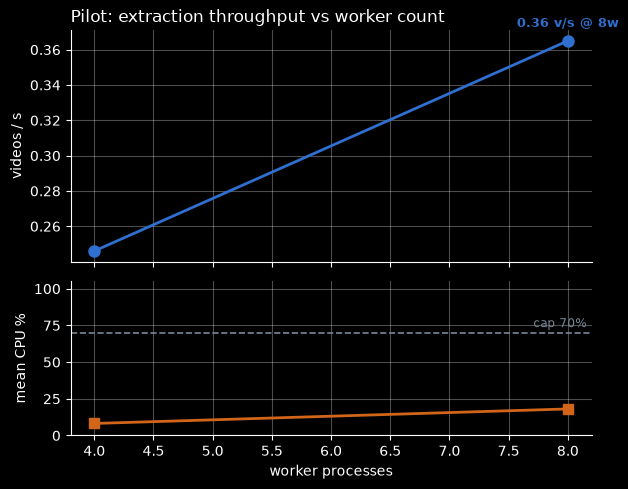

,n_workers,videos_per_s,frames_per_s,cpu_mean_pct,cpu_max_pct,n_failed,elapsed_s
0,4,0.246,28.4,8.2,21.7,0,24.3
1,8,0.365,25.5,18.1,66.7,0,16.4


In [45]:
# ============================================================
# Pilot sweep — HANDOFF: run the benchmark in a terminal, then plot it here
# (pilot npz -> data/temp/popsign_pilot, deleted by the cleanup cell)
# ============================================================
print("Run this in a terminal (worker pools cannot start from a Jupyter kernel):\n")
print("   ", extract_command("pilot",
                             "--worker-counts", *map(str, WORKER_COUNTS),
                             "--videos-per-trial", str(VIDEOS_PER_TRIAL)))
print(f"\n~{len(WORKER_COUNTS) * VIDEOS_PER_TRIAL} extractions; writes "
      f"{NB_CACHE_DIR / 'pilot_results.csv'}\nThen re-run this cell to plot it.\n")

_results_csv = NB_CACHE_DIR / "pilot_results.csv"
if not _results_csv.exists():
    print("no pilot_results.csv yet — run the command above first")
else:
    pilot_results = pd.read_csv(_results_csv)

    # Two measures on different scales: two stacked panels sharing the worker
    # axis, not one chart with two y-axes.
    fig, (ax_t, ax_c) = plt.subplots(2, 1, figsize=(6.4, 5), sharex=True,
                                     gridspec_kw={"height_ratios": [3, 2]})
    ax_t.plot(pilot_results["n_workers"], pilot_results["videos_per_s"],
              "o-", color="#2f6fd0", lw=2, ms=8)
    ax_t.set_ylabel("videos / s")
    ax_t.set_title("Pilot: extraction throughput vs worker count", loc="left")
    _best = pilot_results.loc[pilot_results["videos_per_s"].idxmax()]
    ax_t.annotate(f"{_best['videos_per_s']:.2f} v/s @ {int(_best['n_workers'])}w",
                  xy=(_best["n_workers"], _best["videos_per_s"]),
                  xytext=(0, 10), textcoords="offset points",
                  ha="center", fontsize=9, color="#2f6fd0", fontweight="bold")

    ax_c.plot(pilot_results["n_workers"], pilot_results["cpu_mean_pct"],
              "s-", color="#d1651a", lw=2, ms=7)
    ax_c.axhline(CPU_FRACTION * 100, color="#7a8794", ls="--", lw=1.2)
    ax_c.annotate(f"cap {CPU_FRACTION:.0%}", xy=(0.99, CPU_FRACTION * 100),
                  xycoords=("axes fraction", "data"), xytext=(0, 4),
                  textcoords="offset points", ha="right", fontsize=8.5,
                  color="#7a8794")
    ax_c.set_ylabel("mean CPU %")
    ax_c.set_xlabel("worker processes")
    ax_c.set_ylim(0, 105)
    for ax in (ax_t, ax_c):
        ax.grid(alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(NB_CACHE_DIR / "pilot_throughput.png", dpi=130)
    plt.show()
    display(pilot_results)

In [46]:
# ============================================================
# Pick the operating point + project full-run ETA & disk usage
# ============================================================
pilot_results = pd.read_csv(NB_CACHE_DIR / "pilot_results.csv")

# best throughput among trials that respected the CPU cap (small tolerance)
_ok = pilot_results[pilot_results["cpu_mean_pct"] <= CPU_FRACTION * 100 + 5]
best = (_ok if len(_ok) else pilot_results).sort_values(
    "videos_per_s", ascending=False).iloc[0]
BEST_N_WORKERS = int(best["n_workers"])
vps = float(best["videos_per_s"])

# disk projection from the pilot npz files (temp tree — run before cleanup;
# on a re-run after cleanup the recorded eta.json mean is reused)
_pilot_npz = list(PILOT_ROOT.rglob("*.npz")) if PILOT_ROOT.exists() else []
if _pilot_npz:
    _mean_npz_mb = float(np.mean([p.stat().st_size for p in _pilot_npz]) / 1e6)
elif (NB_CACHE_DIR / "eta.json").exists():
    _mean_npz_mb = json.loads((NB_CACHE_DIR / "eta.json").read_text())["mean_npz_mb"]
else:
    _mean_npz_mb = float("nan")

eta = {"best_n_workers": BEST_N_WORKERS, "videos_per_s": vps,
       "mean_npz_mb": round(float(_mean_npz_mb), 3)}
for split, df in [("train", pd.read_csv(TRAIN_CSV)), ("test", pd.read_csv(TEST_CSV))]:
    manifest = ex.load_manifest(OUT_ROOT / split)
    pending = len(ex.pending_jobs(df, OUT_ROOT / split, dict(manifest)))
    eta[split] = {"videos": len(df), "pending": pending,
                  "eta_h": round(pending / vps / 3600, 1),
                  "projected_gb": round(len(df) * _mean_npz_mb / 1e3, 1)}
(NB_CACHE_DIR / "eta.json").write_text(json.dumps(eta, indent=2))
print(json.dumps(eta, indent=2))

{
  "best_n_workers": 8,
  "videos_per_s": 0.365,
  "mean_npz_mb": 0.236,
  "train": {
    "videos": 30867,
    "pending": 30867,
    "eta_h": 23.5,
    "projected_gb": 7.3
  },
  "test": {
    "videos": 33600,
    "pending": 1,
    "eta_h": 0.0,
    "projected_gb": 7.9
  }
}


In [47]:
# ============================================================
# Pilot cleanup — the pilot npz output is throwaway (data/temp policy):
# delete the whole temp tree now that eta.json + pilot_results.csv are
# recorded in data/cache/popsign/extraction/. Safe to re-run.
# ============================================================
assert (NB_CACHE_DIR / "eta.json").exists(), \
    "run the ETA cell first — cleanup would discard the unmeasured pilot output"
cleanup_temp()
print(f"deleted temp tree ({TEMP_DIR}) — pilot measurements persist in {NB_CACHE_DIR}")

deleted temp tree (C:\Users\user2\sign2speech\src\data\temp) — pilot measurements persist in C:\Users\user2\sign2speech\src\data\cache\popsign\extraction


## 3. Full extraction — train

**Handoff cell.** The bulk run is `extract_popsign.py run train`; the cell below
prints the command (with the chosen worker count and `CONFIDENCE_CONFIG` baked
in) and reports current progress from the split manifest.

Resumable: Ctrl-C the script at any time — npz writes are atomic and the manifest
only ever runs behind reality, never ahead — and re-running the same command skips
everything already done. `--limit N` allows staged runs (e.g. `--limit 2000`
tonight, no limit for the rest). The script shows one progress bar with live
CPU/RAM and failure count; expect the `eta.json` wall time from §2.

Because state lives in the manifest and not in the kernel, **re-run this cell any
time to check progress** while the script runs in a terminal.

In [48]:
# ============================================================
# FULL RUN — train split: HANDOFF + progress readback
# ============================================================
LIMIT = None    # int → tell the script to process only that many pending videos

_eta_file = NB_CACHE_DIR / "eta.json"
_args = ["run", "train"]
if _eta_file.exists():
    _n = int(json.loads(_eta_file.read_text())["best_n_workers"])
    _args += ["--workers", str(_n)]
    print(f"worker count from eta.json: {_n}")
else:
    print("no eta.json — run §2 first (the script falls back to the CPU cap)")
if LIMIT is not None:
    _args += ["--limit", str(LIMIT)]

print("\nRun this in a terminal:\n")
print("   ", extract_command(*_args))
print("\nProgress (from the manifest — re-run this cell any time):")
print("   ", split_progress("train"))

worker count from eta.json: 8

Run this in a terminal:

    .venv/Scripts/python.exe src/modules/scripts/extract_popsign.py run train --workers 8 --confidence default --cpu-fraction 0.7 --ram-limit-pct 70.0

Progress (from the manifest — re-run this cell any time):
    {'split': 'train', 'total': 30867, 'done': 0, 'failed': 0, 'pct': 0.0}


## 4. Full extraction — test

**Handoff cell**, identical to §3 for the test split.

In [49]:
# ============================================================
# FULL RUN — test split: HANDOFF + progress readback
# ============================================================
LIMIT = None    # int → tell the script to process only that many pending videos

_eta_file = NB_CACHE_DIR / "eta.json"
_args = ["run", "test"]
if _eta_file.exists():
    _n = int(json.loads(_eta_file.read_text())["best_n_workers"])
    _args += ["--workers", str(_n)]
    print(f"worker count from eta.json: {_n}")
else:
    print("no eta.json — run §2 first (the script falls back to the CPU cap)")
if LIMIT is not None:
    _args += ["--limit", str(LIMIT)]

print("\nRun this in a terminal:\n")
print("   ", extract_command(*_args))
print("\nProgress (from the manifest — re-run this cell any time):")
print("   ", split_progress("test"))

worker count from eta.json: 8

Run this in a terminal:

    .venv/Scripts/python.exe src/modules/scripts/extract_popsign.py run test --workers 8 --confidence default --cpu-fraction 0.7 --ram-limit-pct 70.0

Progress (from the manifest — re-run this cell any time):
    {'split': 'test', 'total': 33600, 'done': 33599, 'failed': 1, 'pct': 100.0}


## 5. QC — manifest stats, failures, npz spot-checks

Reads only the split manifests and npz artifacts (no video access), so this is
cheap to re-run at any point mid-extraction to check progress and health.

In [50]:
# ============================================================
# QC over both splits — progress, failures, npz spot-check
# ============================================================
N_QC_SAMPLES = 5   # npz files load-checked per split
rng = np.random.default_rng(SEED)

for split in ["train", "test"]:
    manifest = ex.load_manifest(OUT_ROOT / split)
    if not manifest:
        print(f"{split}: no manifest yet — extraction not started\n")
        continue
    st = pd.Series({k: v["status"] for k, v in manifest.items()})
    done = st[st == "done"].index
    print(f"{split}: {len(st):,} attempted — {(st == 'done').sum():,} done · "
          f"{(st == 'failed').sum():,} failed")
    fails = {k: v["error"] for k, v in manifest.items() if v["status"] == "failed"}
    if fails:
        print("  failure reasons (top):")
        print(pd.Series(list(fails.values())).value_counts().head(5).to_string())
    nf = pd.Series({k: manifest[k].get("n_frames") for k in done}).dropna()
    if len(nf):
        print(f"  frames/video: median {nf.median():.0f} · p5 {nf.quantile(.05):.0f} "
              f"· p95 {nf.quantile(.95):.0f} · zero-frame videos {(nf == 0).sum()}")
    for vid in rng.choice(done, size=min(N_QC_SAMPLES, len(done)), replace=False):
        z = np.load(manifest[vid]["artifact"])
        lm = z["landmarks"]
        assert lm.ndim == 3 and lm.shape[1:] == (543, 3), f"bad shape {lm.shape}: {vid}"
        nan_frac = float(np.isnan(lm.astype(np.float32)).mean()) if len(lm) else 1.0
        print(f"  ok {vid}: {lm.shape} float16 · NaN {nan_frac:.1%} · fps {float(z['fps']):.0f}")
    _sz = sum(Path(manifest[k]["artifact"]).stat().st_size
              for k in done if Path(manifest[k]["artifact"]).exists())
    print(f"  on disk: {_sz / 1e9:.2f} GB\n")

train: no manifest yet — extraction not started



test: 33,600 attempted — 33,599 done · 1 failed
  failure reasons (top):
OSError('cannot open video: C:/Users/user2/.cache/kagglehub/datasets/mrgeislinger/popsign-asl-v1-0-game-test/versions/1/into/into/gtsignstudy4a.8035-into-2023_01_30_12_00_12.563-0.mp4')    1
  frames/video: median 60 · p5 47 · p95 248 · zero-frame videos 0
  ok gtsignstudy4a.8038-fast-2023_01_26_11_19_45.419-0: (52, 543, 3) float16 · NaN 4.0% · fps 30
  ok gtsignstudy4a.8035-red-2023_01_31_12_07_58.445-0: (76, 543, 3) float16 · NaN 6.5% · fps 30
  ok gtsignstudy4a.8037-helicopter-2023_01_28_18_52_30.925-0: (51, 543, 3) float16 · NaN 6.1% · fps 30
  ok gtsignstudy4a.8031-tree-2023_01_25_19_31_54.844-0: (45, 543, 3) float16 · NaN 5.3% · fps 30
  ok gtsignstudy4a.8035-pizza-2023_01_26_17_05_08.814-0: (83, 543, 3) float16 · NaN 6.6% · fps 30
  on disk: 6.74 GB



## Caveats & follow-ups

- **The worker pool cannot run in this notebook.** `multiprocessing` spawn +
  Jupyter on Windows hangs silently at 0% forever (no traceback, no files, idle
  CPU). `extraction._assert_pool_usable` refuses it up front; the pilot and bulk
  runs go through `modules/scripts/extract_popsign.py`. `n_workers=1` runs
  genuinely in-process and is the only in-notebook mode, fine for a smoke test.
  Same defect and same fix as the confidence-tuning notebook (TODO §2.3).
- **Manifests currently cover 1 of 4 POPSIGN train datasets** — the other three
  (~650GB) are commented out in `modules/paths.py` (`resolve_datasets()`).
  Enable + download them, then regenerate the manifests and simply re-run the §3
  command (resumability makes the union incremental). Tracked in TODO §2.2.
  The manifests were also **cleared in the 2026-07-18 restructure** and need
  regenerating before any of this runs at all (TODO §0.4).
- **`CONFIDENCE_CONFIG` is an interim choice.** The confidence sweep
  (`docs/reports/confidence-tuning.md`) has 2 of 7 arms measured, and its quality
  proxies are currently contaminated by clip padding — ~half of every POPSIGN clip
  is lead-in/lead-out with no hands in it. `"default"` leads the paired comparison
  that exists, and the spread across arms is ~0.02 of hand-detection rate, so this
  is unlikely to be the decision that matters. Re-check before committing the full
  ~64K-video run.
- The pilot ETA is an **upper bound** (warm-up bias) but assumes the machine is
  otherwise idle; heavy concurrent use (e.g. GPU training with data loading)
  will stretch it.
- Pilot output lives in `data/temp/popsign_pilot/` and is deleted by the §2
  cleanup cell — per the repo temp policy, nothing under `data/temp/` survives
  the notebook that wrote it.
- `fps` is taken from the container metadata (`cv2.CAP_PROP_FPS`, fallback 30
  when the container reports 0) and is stored per npz; downstream consumers
  should not assume a uniform frame rate across POPSIGN.
- Landmark values are float16 (halves storage; x/y are normalized [0,1] where
  ~3 significant digits survive, which is far above landmark jitter).